<header style="text-align:center;">
  <h1 style="color:#FF8C00; font-family:Arial, sans-serif; margin-bottom:0;">
    Imagerie Hyperspectrale
  </h1>
  <h2 style="color:#E76F51; font-family:Arial, sans-serif; margin-top:5px;">
    TP IMA207
  </h2>
  <p style="font-weight:bold; color:#2A9D8F; font-family:Arial, sans-serif;">
    Name : Le Guillouzic Maël
  </p>
</header>

In [77]:
import numpy as np
import tempfile
import os
import matplotlib.pyplot as plt
import scipy.io as sci
import scipy.fftpack as sff

from sklearn.metrics.pairwise import cosine_similarity

<h1 style="color:#FF8C00; font-family:Arial, sans-serif;">
  I - Data generation and manipulation
</h1>

The objective of this first short part is to create some datasets to get accustomed to them. It will enable us to :
- recall the notion of sparsity ;
- geometrically understand the effect of the mixing.

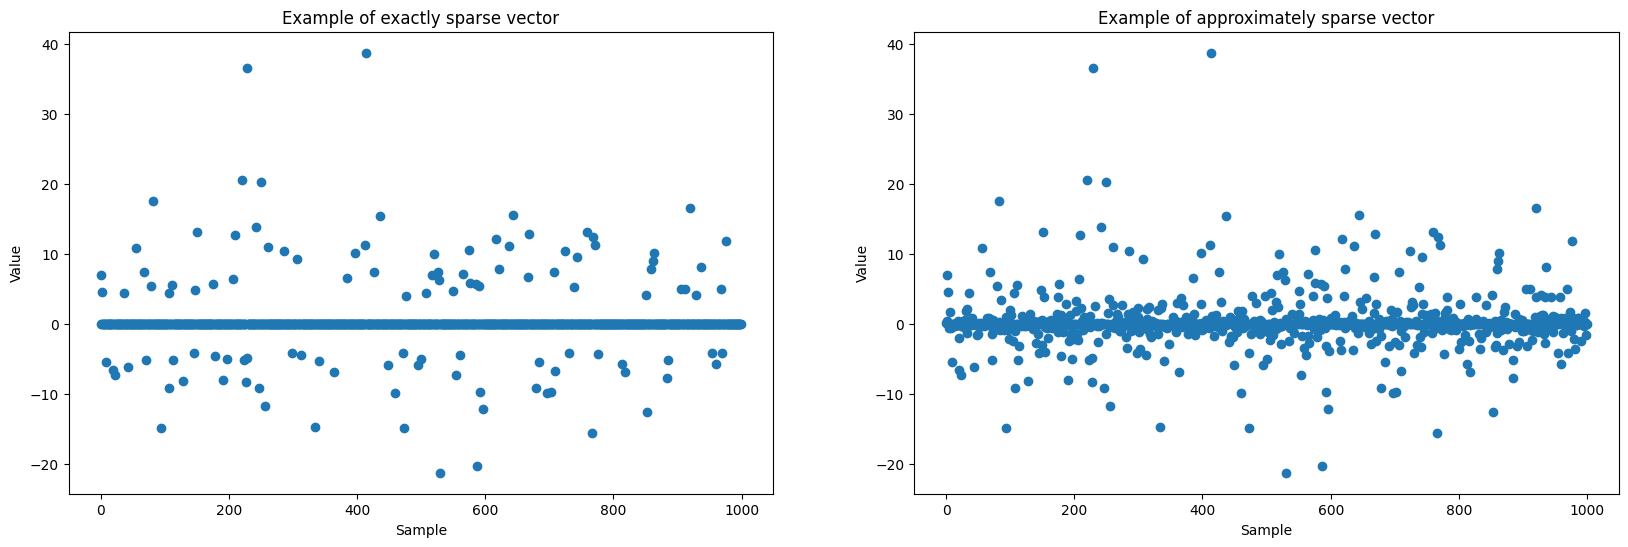

In [51]:
power = 3
approx_sparse = np.random.randn(1000)**power
exact_sparse = approx_sparse*(np.abs(approx_sparse)>4)

fig = plt.figure(figsize=(20, 6))
fig.add_subplot(1,2,1)
plt.plot(exact_sparse, 'o')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Example of exactly sparse vector');

fig.add_subplot(1,2,2)
plt.plot(approx_sparse, 'o')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Example of approximately sparse vector');

What is the difference between an exactly and an approximately sparse signal? Recall the two corresponding definitions.

Now let's start to look at some mixtures and to try to geometrically interpret the impact of the mixing.

First, generate a simulated source S matrix. Plot the corresponding scatter plot. Interpret the shape of the scatter plot you obtain.

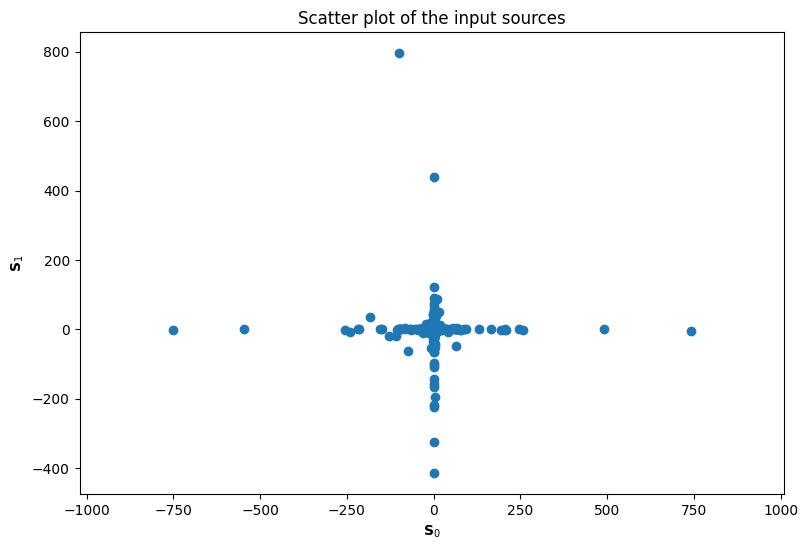

In [52]:
n = 2         # number of sources
t = 1024      # number of samples
noise_level = 80 # noise level, in dB
power = 5 # power exponent used in the source generation



# TO DO : generate a simulated source S matrix.
# S will be of dimensions n x t.
# Each of the n sources (i.e. lines of S) will follow the approximately sparse
# law we used above.
S = np.random.randn(n, t)**power

fig = plt.figure(figsize=(20, 6))
fig.add_subplot(1,2,1)
plt.title('Scatter plot of the input sources')
plt.plot(S[0, :], S[1, :], 'C0o')
plt.xlabel("$\mathbf{S}_0$")
plt.ylabel("$\mathbf{S}_1$")
plt.axis('equal');

In [53]:
# Here, we generate a mixture matrix (dimensions m x t) from the sources in S
m = 4         # number of observations

A = np.random.randn(m,n)
X = A@S

noise_level = 120

# To be more realistic, we add some noise to the mixing.
# Mixtures with SNR > 120 dB can be considered as noiseless for most applications.
if noise_level < 120:
    #--- Add noise
    N = np.random.randn(m,t)
    N = 10.**(-noise_level/20.)*np.linalg.norm(X)/np.linalg.norm(N)*N
    X = X + N

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Questions :</strong>
</h4>

- Plot the scatter plot of X. What do you see ?
- What do the directions of the lines you observe correspond ?
- Try several A matrices, noise_values and powers. Any comment?

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Réponses :</strong>
</h4>

- On observe une structure en croix, mais dont les axes ont une orientation différente. Les points se concentrent encore le long de ces deux axes.
- Les deux axes noirs correspondent aux signatures hyperspectrales principales.
- On teste plusieures matrices A :
    - Cela change l'angle entre les deux lignes noires à chaque fois
    - Plus on ajoute du bruit plus les points sont dispersés autour des lignes
    - Plus on augmente la puissance et plus la sparsité augmente

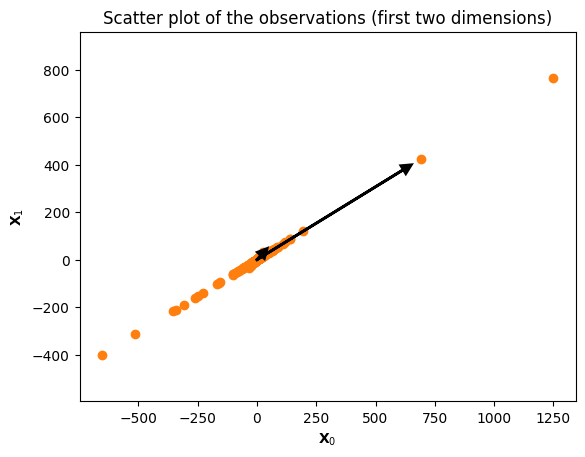

In [54]:
plt.title('Scatter plot of the observations (first two dimensions)')
vrange = 0.25*max(np.sqrt(np.sum(X*X, 0)))
plt.arrow( 0, 0, vrange*A[0, 0], vrange*A[1, 0], fc="k", ec="k", linewidth=2, head_width=0.1*vrange, head_length=0.1*vrange)
plt.arrow( 0, 0, vrange*A[0, 1], vrange*A[1, 1], fc="k", ec="k", linewidth=2, head_width=0.1*vrange, head_length=0.1*vrange)
plt.plot(X[0,:], X[1,:], 'C1o', zorder=0)
plt.xlabel("$\mathbf{X}_0$")
plt.ylabel("$\mathbf{X}_1$")
plt.axis('equal');

<h1 style="color:#FF8C00; font-family:Arial, sans-serif;">
  II - Performing non-blind source separation
</h1>

<h2 style="color:#006400; font-family:Arial, sans-serif;">
  1) Data generation
</h2>

Before going into blind source separation, in which we want to find physical **A** and **S** matrices such that **X = AS + N**, let us first consider the simpler setting in which we know **A** and want to recover **S**.
We will consider the noisy mixture of two sine signals. The methodology extends to more complex datasets.

N.B. : unmixing two sinus signal could be done much more easily than using the algorithms we saw during the class. Nevertheless, focusing on such synthetic data enables an easy visualization. The principle readily extend to more complex datasets, such as images.

(-25.0, 25.0)

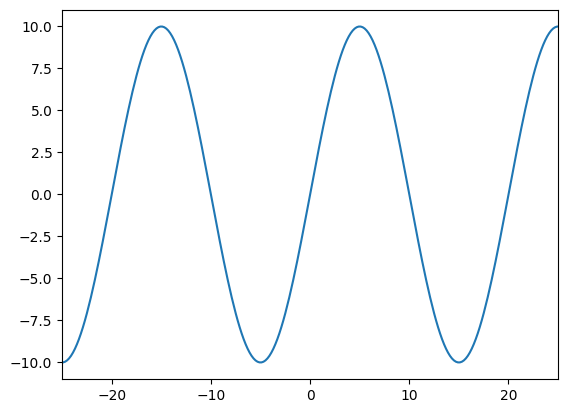

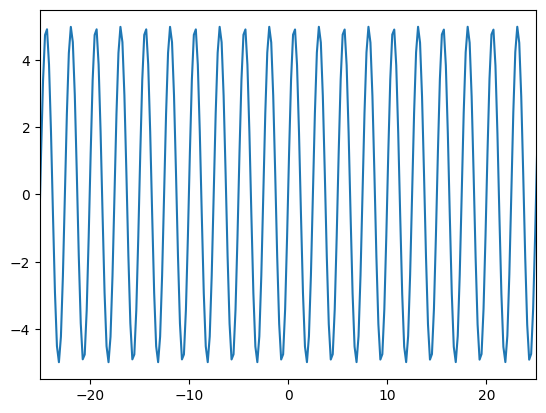

In [55]:
# Source generation
t = 10000
x_abs = np.linspace(-1000,1000,t)

S = np.zeros((2,t))
S[0,:] = 10*np.sin(2*np.pi*0.05*x_abs)
S[1,:] = 5*np.sin(2*np.pi*0.4*x_abs)

plt.figure(),plt.plot(x_abs,S[0,:])
plt.xlim([-25,25])
plt.figure(),plt.plot(x_abs,S[1,:])
plt.xlim([-25,25])

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Questions :</strong>
</h4>

Here, we will transform the sources signals S into the DCT domain.
- What is the objective of using the DCT?
- Plot the above DCT and justify what you see. Pay attention to the labeling of the x-axis. Try with sines of various frequencies.

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Réponses :</strong>
</h4>

- La DCT permet de rendre un signal qui n'était pas sparse (comme un sinus) en un signal très sparse ! (un seul pic). Ca sera donc bien plus simple pour l'unmixing.
- On plot les DCT et on observe 2 pics, correspondants aux deux fréquences générées.

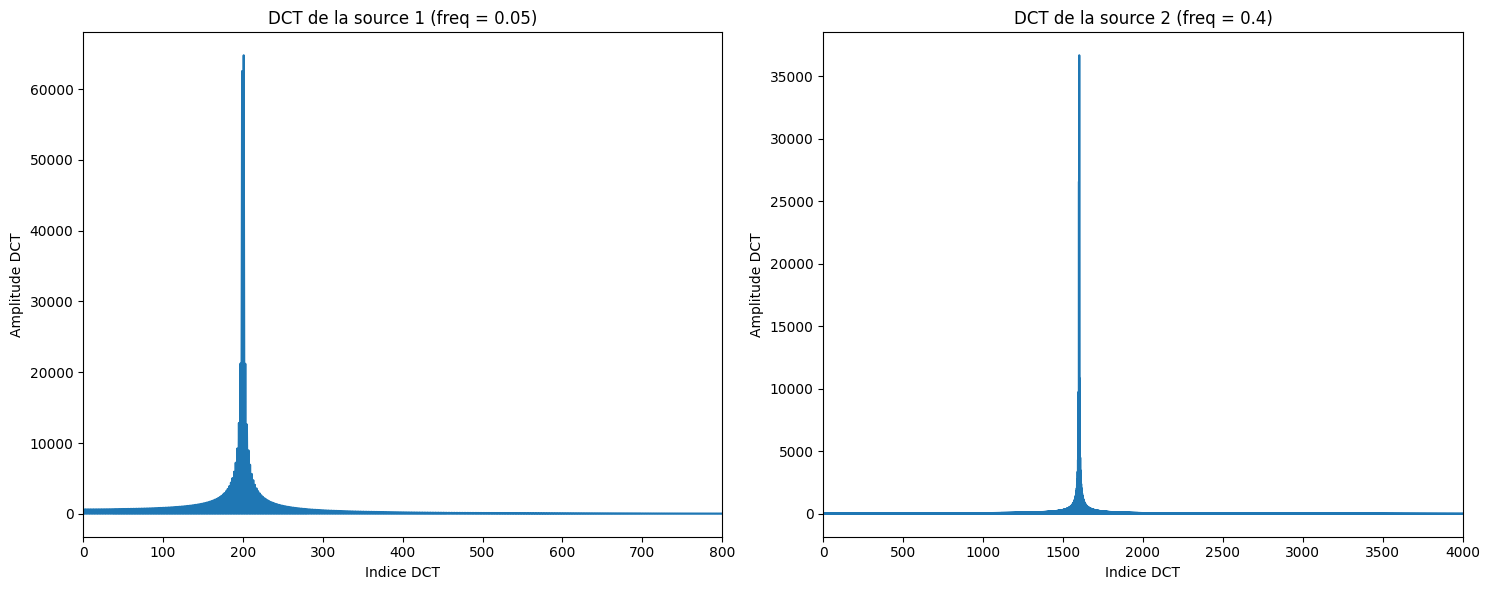

In [56]:
# Transformation into the DCT domain
Sf = sff.dct(S, axis=1)

freq_axis = np.arange(t)
plt.figure(figsize=(15, 6))

# DCT de la première source
plt.subplot(1, 2, 1)
plt.plot(freq_axis, np.abs(Sf[0,:]))
plt.title('DCT de la source 1 (freq = 0.05)')
plt.xlabel('Indice DCT')
plt.ylabel('Amplitude DCT')
plt.xlim([0,800])

# DCT de la seconde source
plt.subplot(1, 2, 2)
plt.plot(freq_axis, np.abs(Sf[1,:]))
plt.title('DCT de la source 2 (freq = 0.4)')
plt.xlabel('Indice DCT')
plt.ylabel('Amplitude DCT')
plt.xlim([0,4000])

plt.tight_layout()
plt.show()

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Questions :</strong>
</h4>

Data generation : now, we will create a mixture X = AS + N.
- Plot the mixtures. Explain what you see.
- Compute the DCT of X. Plot it and explain. Which caracteristic of the DCT will we use to recover the sources?

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Réponses :</strong>
</h4>

- on observe 2 signaux qui sont une combinaison linéaire des deux sources sinusoïdales. On ne distingue plus les deux fréquences pures.
- On affiche les DCT et on retrouve deux pics ! et deux signaux très sparses.


In [57]:
A = np.array([[0.5547002 , 0.24253563],
       [0.83205029, 0.9701425 ]]) # You can try other A values, but the columns must have a unitary norm.

X = A@S
X = X + 0.5*np.random.randn(np.shape(X)[0],np.shape(X)[1])# You can try other noise values

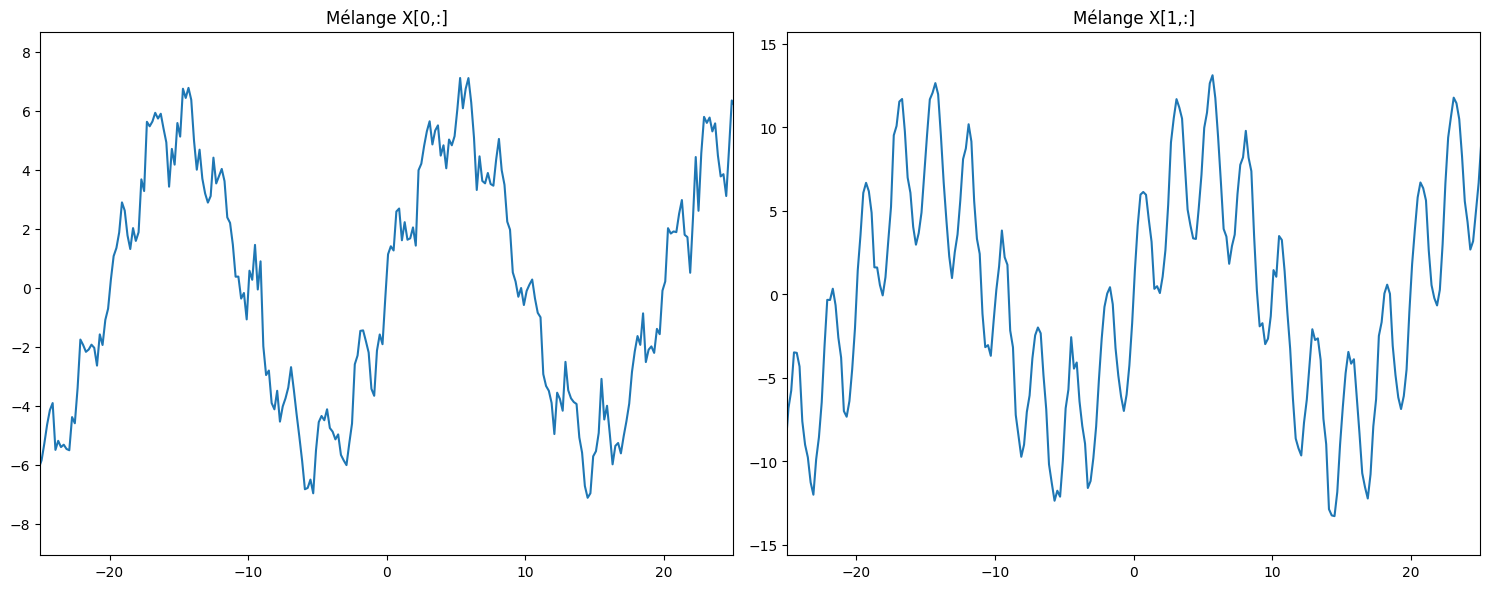

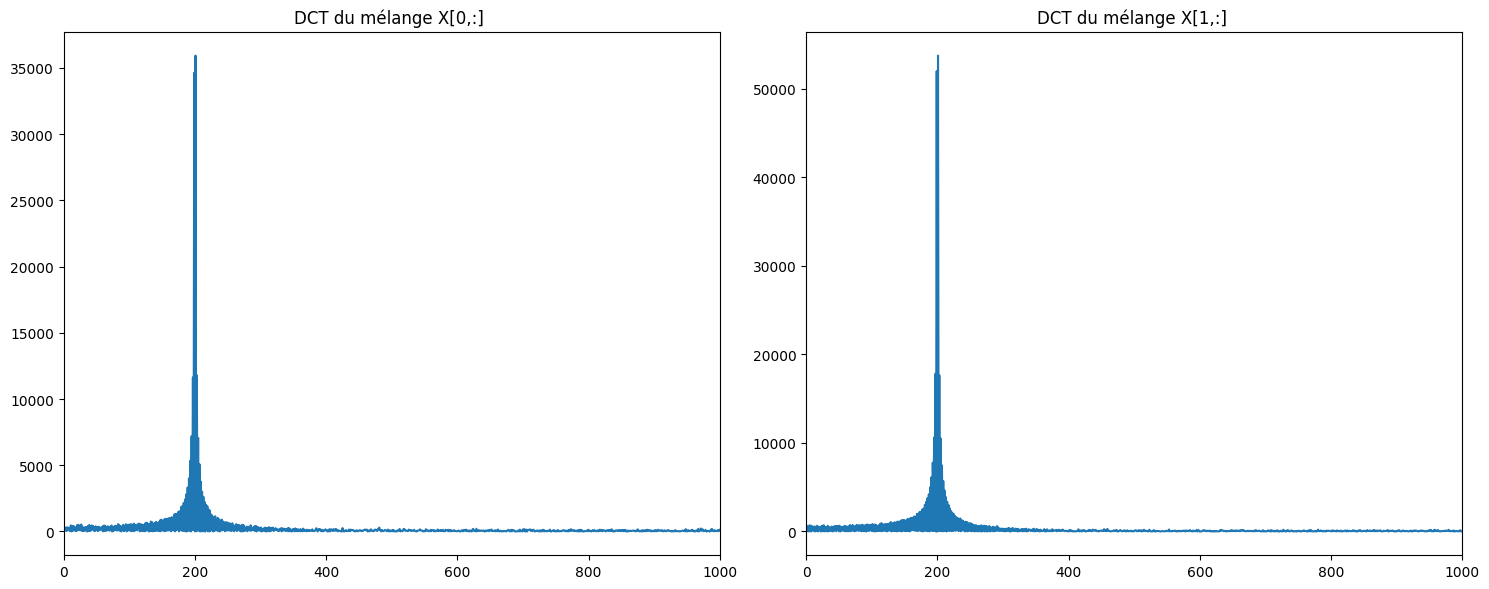

In [58]:
# mélanges
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(x_abs, X[0,:])
plt.title('Mélange X[0,:]')
plt.xlim([-25, 25])
plt.subplot(1, 2, 2)
plt.plot(x_abs, X[1,:])
plt.title('Mélange X[1,:]')
plt.xlim([-25, 25])
plt.tight_layout()
plt.show()

# DCT des mélanges
Xf = sff.dct(X, axis=1)
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(freq_axis, np.abs(Xf[0,:]))
plt.title('DCT du mélange X[0,:] ')
plt.xlim([0, 1000])
plt.subplot(1, 2, 2)
plt.plot(freq_axis, np.abs(Xf[1,:]))
plt.title('DCT du mélange X[1,:] ')
plt.xlim([0, 1000])
plt.tight_layout()
plt.show()

<h2 style="color:#006400; font-family:Arial, sans-serif;">
  2) Source separation
</h2>

Now that we generated observations from simulated sources, we will focus on the source separation problem: recovering the sources from the observations (and the knowledge of A, since we are here in the non-blind setting).

To do that, we propose here to solve the source separation problem using a sparsity constraint on the sources. The cost function will then be minimized using the ISTA algorithm.

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Questions :</strong>
</h4>

First, write the cost function we want to minimize to perform non-blind sparse source separation. 
- Explain each term (in particular, which one is smooth or not). Is this cost function convex?
- Compute the gradient along the S variable of the data-fidelity term.
- Recall what the proximal operator of the l1-norm is.

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Réponses :</strong>
</h4>

La fonction de coût qu'on souhaite minimiser est :
$$J(S) = \frac{1}{2}||X - AS||^2 _F + \lambda ||S||_1$$
où le terme 1 est la fidélité aux données (smooth/lisse) et le terme 2 la régularisation. 

La fonction n'est pas lisse à cause de la norme 1, mais est multi-convexe (si on fixe un terme, elle l'est par rapport à l'autre).

Le gradient du terme de fidélité est :
$$A^T(AS - X)$$

In [59]:
# TO DO: implement the proximal operator of the l1-norm in the above function:
def prox_l1(S_est, thrd):
    S_prox = np.sign(S_est) * np.maximum(np.abs(S_est) - thrd, 0)
    return S_prox

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Questions :</strong>
</h4>

Explain the main idea of the ISTA algorithm. Then, implement it.

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Réponses :</strong>
</h4>

L'idée principale d'ISTA est que ca alterne entre 
- Gradient step sur le terme lisse (fidélité)
- Proximal step sur le terme non-lisse (sparsité)

In [60]:
# TO DO: implement the ISTA algorithm to minimize the cost function you wrote in question II-2-1.
def ISTA(X, A=np.eye(2), n=2, lamb=0, nbIt=100):
    m, t = X.shape
    S_est = np.random.randn(n, t)
    L = np.linalg.norm(A.T @ A, 2)  # Plus grande valeur propre de A^T A
    gamma = 1 / L  # Pas de gradient
    for it in range(nbIt):
        # Gradient step sur terme de fidélité
        gradient = A.T @ (A @ S_est - X)
        S_temp = S_est - gamma * gradient
        # Proximal step sur terme de sparsité
        S_est = prox_l1(S_temp, gamma * lamb)
    return S_est

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Questions :</strong>
</h4>

It's now time to play with the code : 
- launch the ISTA algorithm and look at the results.
- Try various lamb values. What is the minimum value you should no go below? What is the issue with choosing too big values?
- Plot the estimated sources in the DCT domain. What kind of sparsity to they exhibit? Why?

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Réponses :</strong>
</h4>

J'avoue pour tous les lambdas avoir l'impréssion d'un résultat correct quelque soit le lamda... 

Pareil pour les DCT pas de soucis, chaque source est concentrée sur sa fréquence.

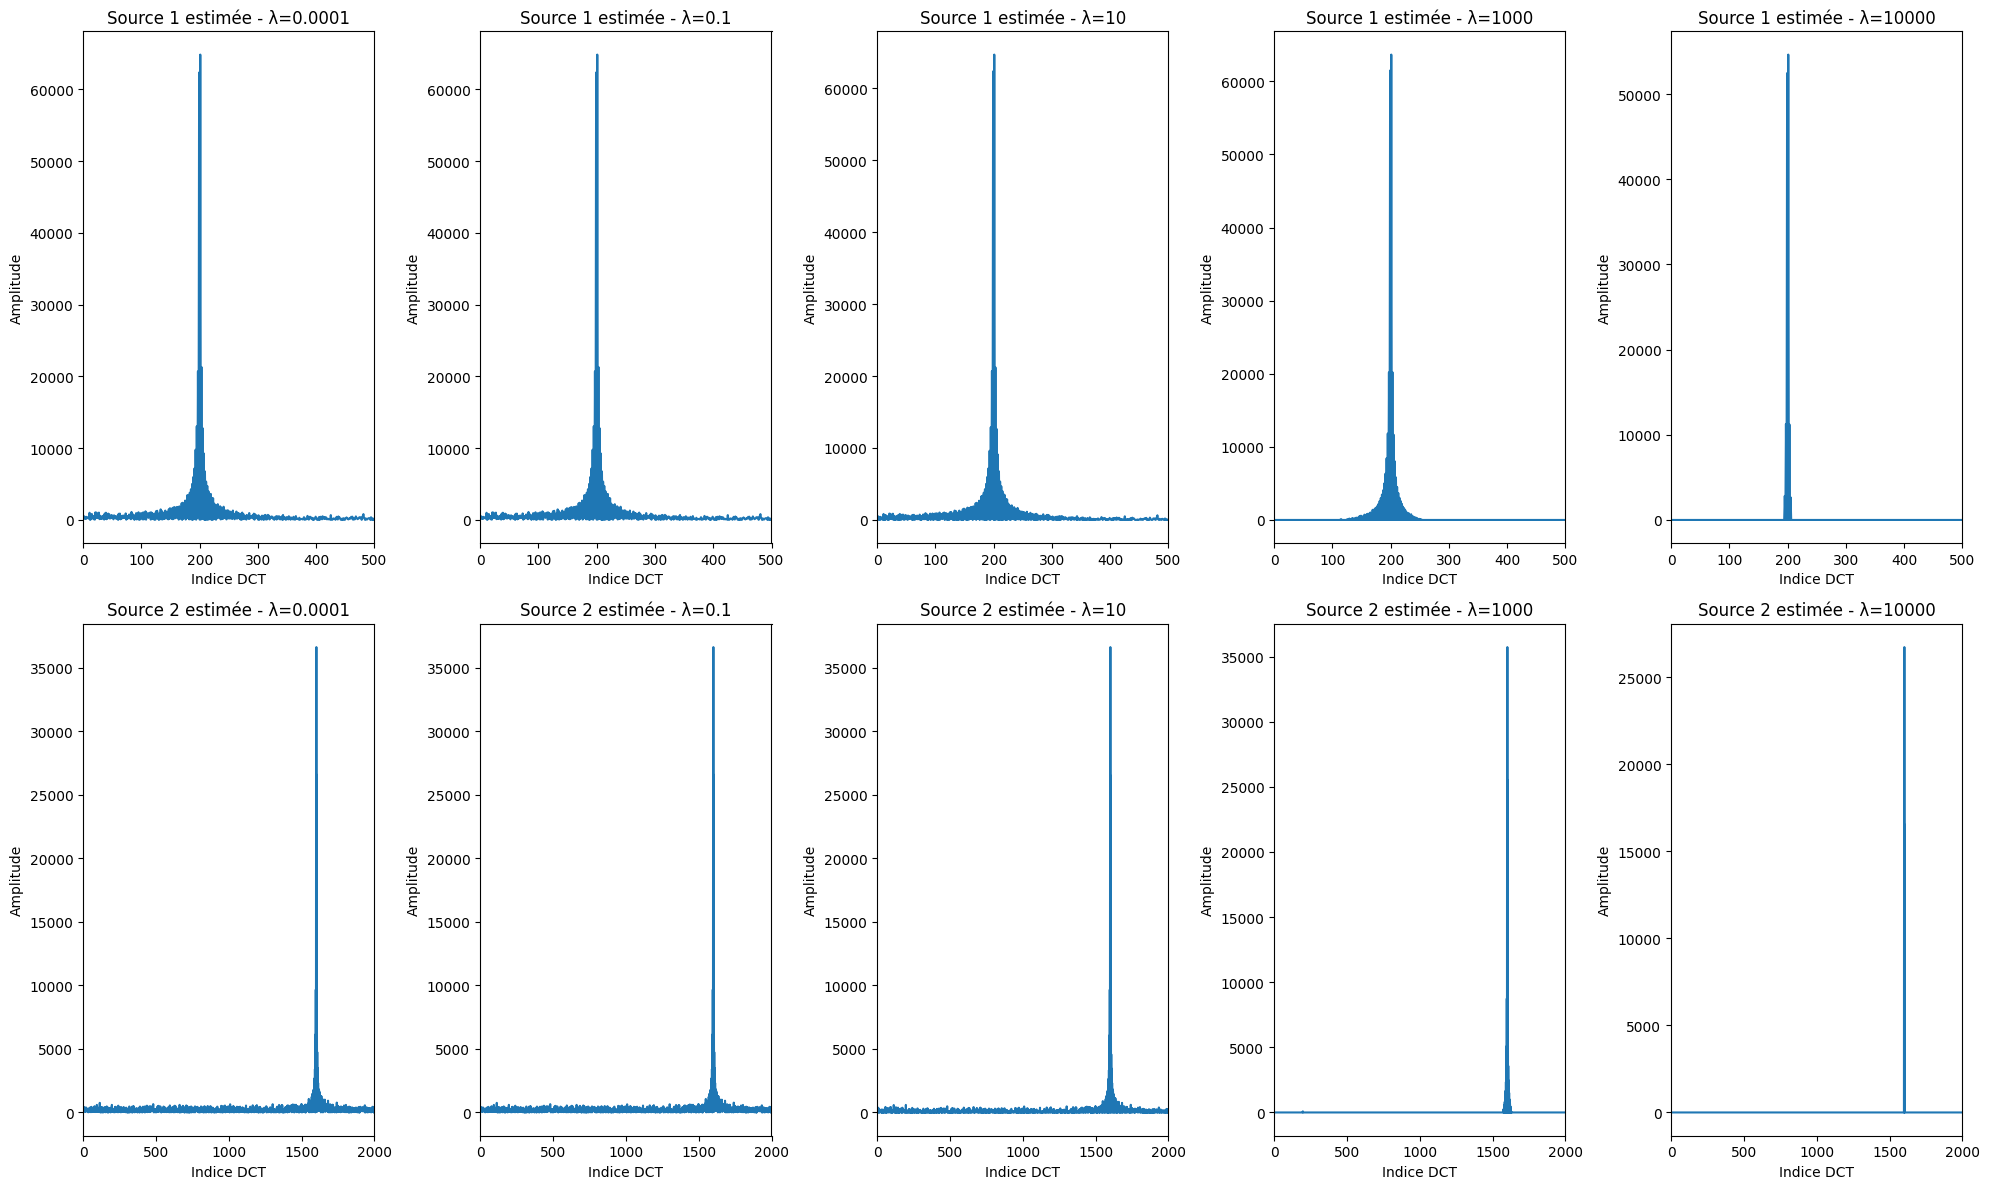

In [61]:
# différentes valeurs de lambda
lambda_values = [0.0001,0.1,10,1000,10000]

plt.figure(figsize=(20, 12))

for i, lamb in enumerate(lambda_values):
    # ISTA
    S_estf = ISTA(Xf, A=A, n=2, lamb=lamb, nbIt=1000)
    
    # plots
    plt.subplot(2, len(lambda_values), i+1)
    plt.plot(freq_axis, np.abs(S_estf[0,:]))
    plt.title(f'Source 1 estimée - λ={lamb}')
    plt.xlabel('Indice DCT')
    plt.ylabel('Amplitude')
    plt.xlim([0,500])
    
    plt.subplot(2, len(lambda_values), i+1+len(lambda_values))
    plt.plot(freq_axis, np.abs(S_estf[1,:]))
    plt.title(f'Source 2 estimée - λ={lamb}')
    plt.xlabel('Indice DCT')
    plt.ylabel('Amplitude')
    plt.xlim([0,2000])

plt.tight_layout()
plt.show()

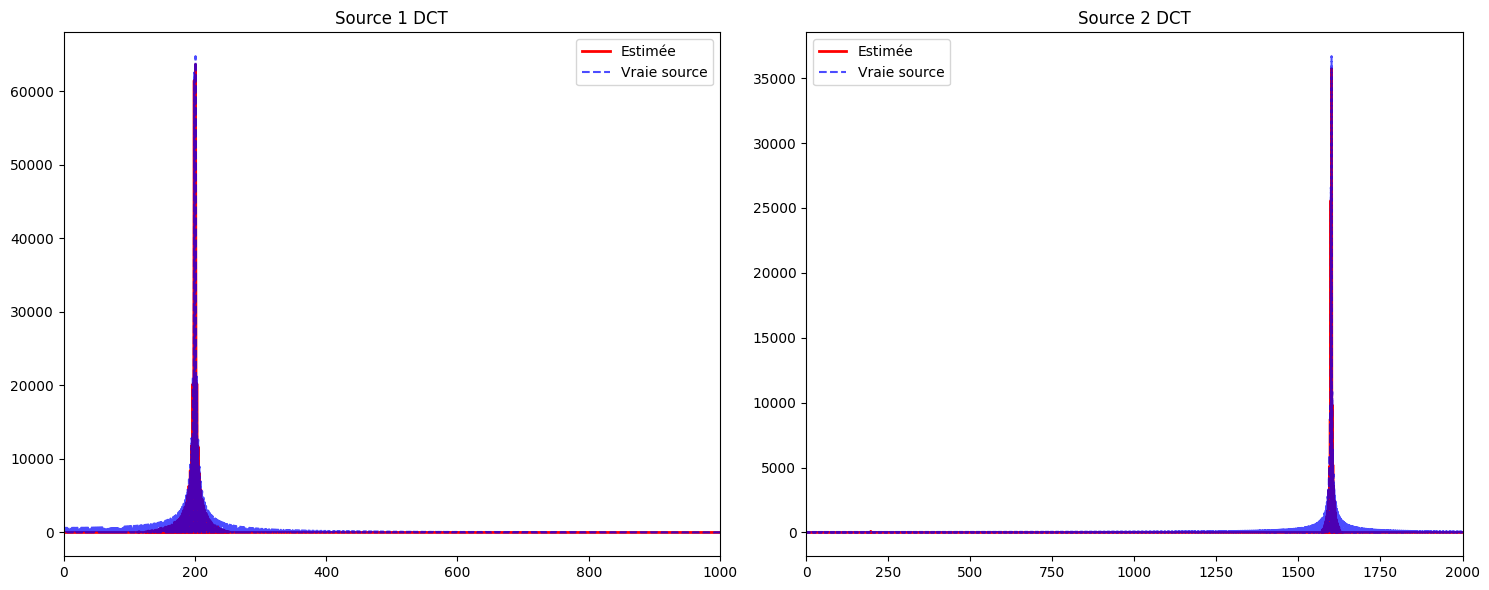

In [62]:
S_estf = ISTA(Xf, A=A, n=2, lamb=1000, nbIt=1000)

# Plot des sources estimées
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(freq_axis, np.abs(S_estf[0,:]), 'r-', linewidth=2, label='Estimée')
plt.plot(freq_axis, np.abs(Sf[0,:]), 'b--', alpha=0.7, label='Vraie source')
plt.title('Source 1 DCT')
plt.xlim([0,1000])
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(freq_axis, np.abs(S_estf[1,:]), 'r-', linewidth=2, label='Estimée')
plt.plot(freq_axis, np.abs(Sf[1,:]), 'b--', alpha=0.7, label='Vraie source')
plt.title('Source 2 DCT')
plt.xlim([0,2000])
plt.legend()

plt.tight_layout()
plt.show()

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Questions :</strong>
</h4>

Transform the sources back in the direct domain. Plot them. What do you see? Explain the differences with the original sources. Conclude.

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Réponses :</strong>
</h4>

Je commence par regarder l'entrée

(2, 10000)


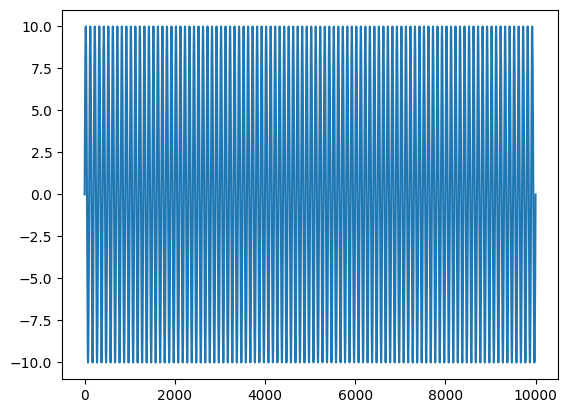

In [72]:
print(S.shape)
plt.figure()
plt.plot(S[0,:])
plt.show()

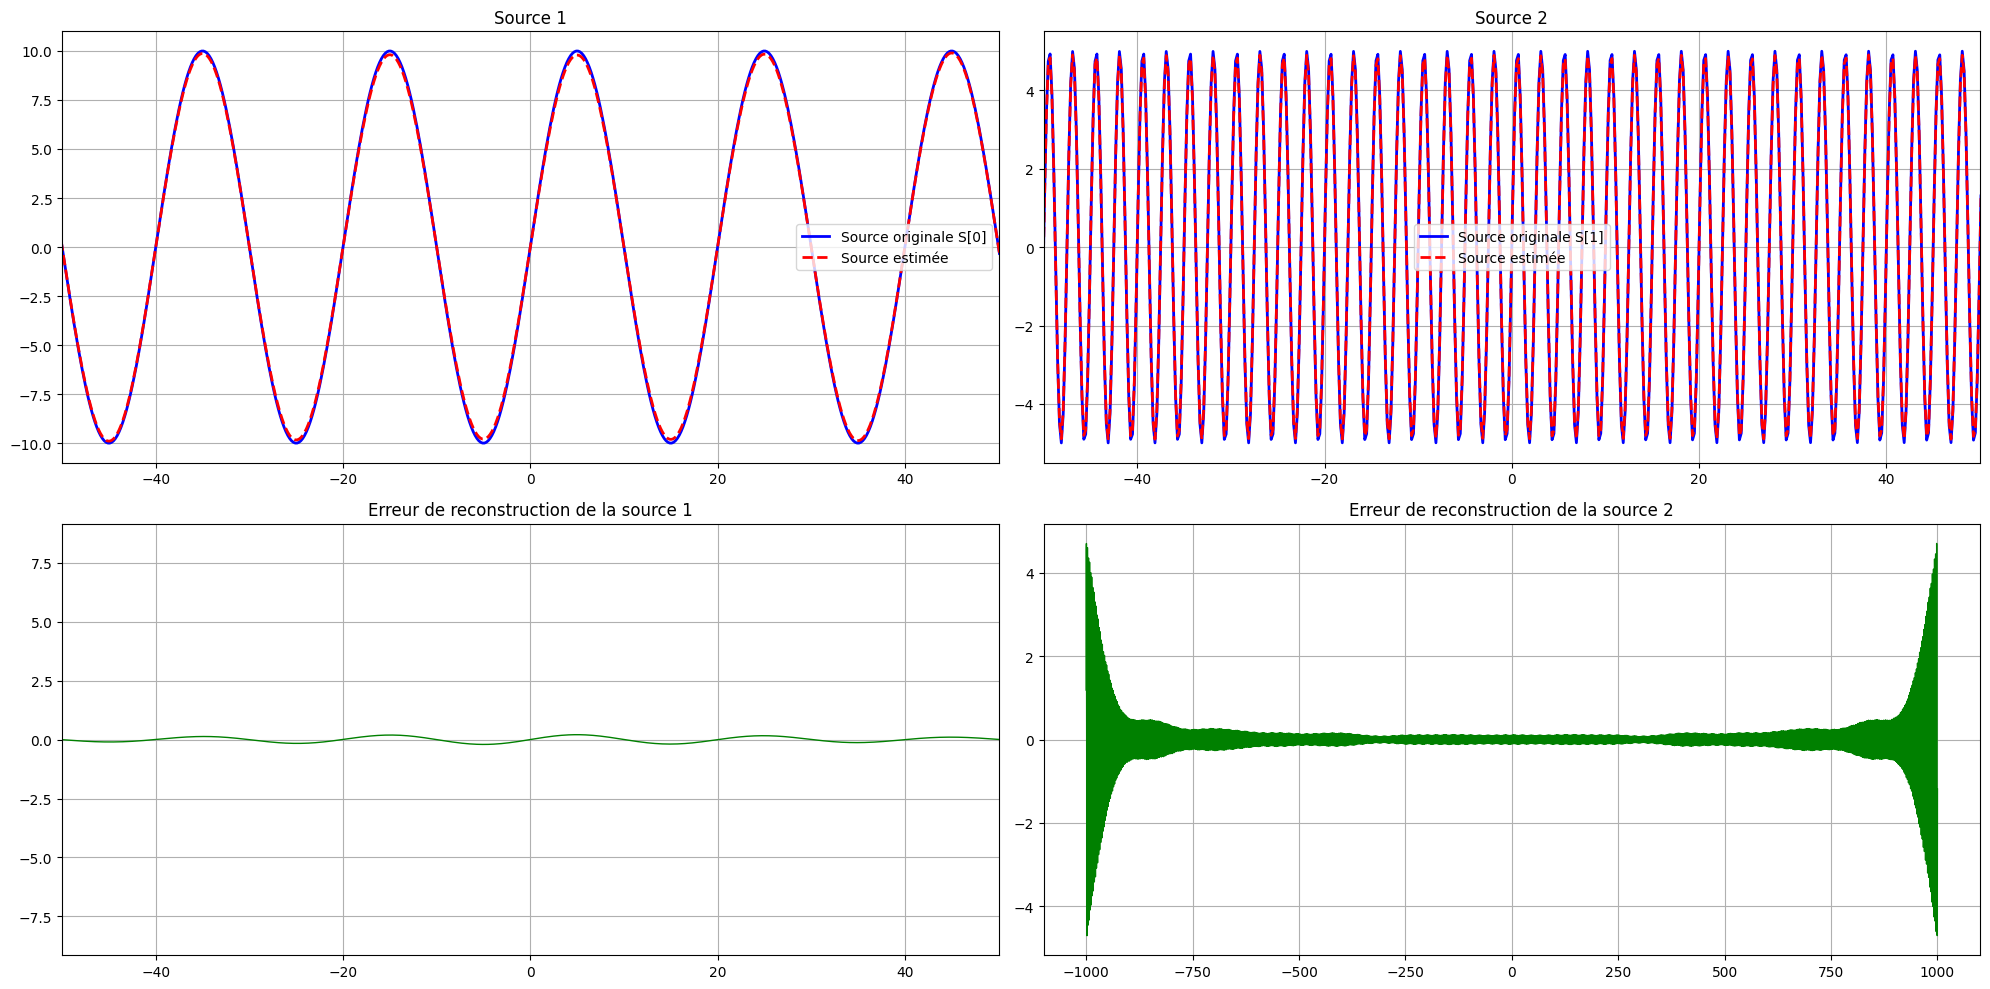

Source 1 MSE: 0.5992
Source 2 MSE: 0.3143


In [73]:
S_est_temporal_raw = sff.idct(S_estf, axis=1, norm=None)
N_samples = S_estf.shape[1] # attention il faut diviser par 2N_samples pour la normalisation
S_est_temporal = S_est_temporal_raw / (2 * N_samples) # sinon la reconstruction explose

plt.figure(figsize=(20, 10))
# Source 1 
plt.subplot(2, 2, 1)
plt.plot(x_abs, S[0,:], 'b-', linewidth=2, label='Source originale S[0]')
plt.plot(x_abs, S_est_temporal[0,:], 'r--', linewidth=2, label='Source estimée')
plt.title('Source 1')
plt.xlim([-50, 50])
plt.legend()
plt.grid(True)

# Source 2 
plt.subplot(2, 2, 2)
plt.plot(x_abs, S[1,:], 'b-', linewidth=2, label='Source originale S[1]')
plt.plot(x_abs, S_est_temporal[1,:], 'r--', linewidth=2, label='Source estimée')
plt.title('Source 2')
plt.xlim([-50, 50])
plt.legend()
plt.grid(True)

# Erreur de reconstruction
plt.subplot(2, 2, 3)
erreur_s1 = S[0,:] - S_est_temporal[0,:]
plt.plot(x_abs, erreur_s1, 'g-', linewidth=1)
plt.title('Erreur de reconstruction de la source 1')
plt.xlim([-50, 50])
plt.grid(True)
plt.subplot(2, 2, 4)
erreur_s2 = S[1,:] - S_est_temporal[1,:]
plt.plot(x_abs, erreur_s2, 'g-', linewidth=1)
plt.title('Erreur de reconstruction de la source 2')
plt.grid(True)
plt.tight_layout()
plt.show()

# calcul de la MSE
mse_s1 = np.mean((S[0,:] - S_est_temporal[0,:])**2)
mse_s2 = np.mean((S[1,:] - S_est_temporal[1,:])**2)
print(f"Source 1 MSE: {mse_s1:.4f}")
print(f"Source 2 MSE: {mse_s2:.4f}")

In [69]:
import scipy
print(scipy.__version__)

1.13.1


<h1 style="color:#FF8C00; font-family:Arial, sans-serif;">
  III - Blind Source Separation : PALM
</h1>

Let's now delve into the core problem : *blind* source separation, in which **A** is unknown. To leverage sparsity, we will use the PALM algorithm.

Thoughout this whole section, we will re-use the same synthetic data as above (i.e., the one generated in II-1).

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Question :</strong>
</h4>

Write the cost function we want to minimize to perform *blind* sparse source separation. Explain each term (in particular, which one is smooth or not). Is this cost function convex?

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Réponse :</strong>
</h4>

La fonction de coût à minimiser est :
$$J(A, S) = \frac{1}{2} \|X - AS\|_{\text{F}}^2 + \lambda \|S\|_1 + \iota_{\mathcal{C}}(A)$$
où :
1. $\frac{1}{2} \|X - AS\|_{\text{F}}^2$ est le terme de fidélité aux données, qui mesure le reconstruction entre $X$ et le modèle $AS$
2. $\lambda \|S\|_1$ est le terme de régularisation qui pousse à la sparsité
3. $\iota_{\mathcal{C}}(A)$ est le terme de contrainte sur A pour imposer à chaque colonne une norme qui vaut 1. Il est nécessaire pour lever une ambiguité

La fonction est multiconvexe, c'est à dire qu'en bloquant un paramètre elle l'est par rapport à l'autre.

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Questions :</strong>
</h4>

Recall what the gradient of the data fidelity term over A is.

Compte the proximal operator of the oblique constraint. Implement it.

<h4 style="color:#2A9D8F; font-family:Arial, sans-serif; margin-bottom:10px;">
  <strong>Réponses :</strong>
</h4>

Le gradient du Terme de fidélité par rapport à A est :
$\nabla_A f(A,S) = -(X - AS)S^{\text{T}}$

Pour toute colonne $a_j$ de $A$, l'opérateur Proximal est :
$\text{prox}_{\iota_{\mathcal{C}}}(A) = \frac{a_j}{\|a_j\|_2}$

In [74]:
def prox_oblique(A_input):
    A_projected = np.copy(A_input)
    num_cols = A_projected.shape[1]
    for j in range(num_cols):
        col_j = A_projected[:, j]
        norm_col_j = np.linalg.norm(col_j, 2)
        if norm_col_j > 1e-9: # evite la division par zéro
            A_projected[:, j] = col_j / norm_col_j
    return A_projected

Implement the PALM algorithm to minimize the cost function you wrote in III-1).

In [76]:
def PALM(X_input, n_sources, lambda_s, num_iterations=100, A_init=None, S_init=None):
    m_obs, t_samples = X_input.shape
    A_est = np.random.randn(m_obs, n_sources)
    A_est = prox_oblique(A_est)
    S_est = np.random.randn(n_sources, t_samples)
    for _ in range(num_iterations):
        L_s = np.linalg.norm(A_est.T @ A_est, 2)
        gamma_s = 1.0 / L_s if L_s > 1e-9 else 1.0
        grad_S = A_est.T @ (A_est @ S_est - X_input)
        S_temp = S_est - gamma_s * grad_S
        S_est = prox_l1(S_temp, gamma_s * lambda_s)

        L_a = np.linalg.norm(S_est @ S_est.T, 2)
        gamma_a = 1.0 / L_a if L_a > 1e-9 else 1.0 
        grad_A = (A_est @ S_est - X_input) @ S_est.T
        A_temp = A_est - gamma_a * grad_A
        A_est = prox_oblique(A_temp)
    return A_est, S_est

Launch the PALM algorithm to retrieve both A and S from X. Plot your results. How good is the separation? The separation quality is usually well evaluated comparing the true and estimated A matrices.

In [79]:
lambda_palm = 1000
num_iter_palm = 200

print(f"\n--- Exécution de PALM avec Lambda={lambda_palm} et {num_iter_palm} itérations ---")
A_est_palm, S_estf_palm = PALM(Xf,n_sources=2,lambda_s=lambda_palm,num_iterations=num_iter_palm)
print("\nMatrice A estimée par PALM:\n", A_est_palm)
print("\nMatrice A réelle (A):\n", A)

similarity_matrix = cosine_similarity(A.T, A_est_palm.T)
print("\nSimilarité entre A et A_est_palm:")
print(similarity_matrix)


--- Exécution de PALM avec Lambda=1000 et 200 itérations ---

Matrice A estimée par PALM:
 [[-0.27556422  0.75956054]
 [-0.96128267  0.65043662]]

Matrice A réelle (A):
 [[0.5547002  0.24253563]
 [0.83205029 0.9701425 ]]

Similarité entre A et A_est_palm:
[[-0.95269105  0.96252436]
 [-0.99941531  0.8152367 ]]
